In [1]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib import cm

from src import loader, plotter
from datetime import timedelta

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.fdu import functional_dynamic_update
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

from src.fdu import functional_dynamic_update

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 48
method = 'fusion'
resource = 'wind'
aggregation = 'zone'

In [2]:
# exp_description="unbiased-025-C0"
# _init = {6: 1, 12: 3, 18: 4}

# exp_description="unbiased-025-C1"
# _init = {6: 3, 12: 1, 18: 4}

# exp_description="unbiased-025-C2"
# _init = {6: 2, 12: 5, 18: 5}

# exp_description="biased-025-C0"
# _init = {6: 3, 12: 5, 18: 2}

# exp_description="biased-025-C1"
# _init = {6: 1, 12: 4, 18: 1}

# exp_description="biased-025-C2"
# _init = {6: 4, 12: 4, 18: 1}

# exp_description="unbiased-025-C1"
# _init = {6: 5, 12: 1, 18: 2}

exp_description="unbiased-025-C1-1"
_init = {6: 5, 12: 4, 18: 3}

exp_description="unbiased-025-C1-6"
_init = {6: 4, 12: 4, 18: 4}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation=VALIDATION,
)

hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)

# stats_, funcs_ = loader.get_zone_stats(
#     _init, 
#     resource, 
#     method, 
#     aggregation, 
#     exp_description, 
#     T, 
#     VALIDATION, 
# )
# print(stats_)
# print(funcs_)
dates_ = np.random.default_rng(1234).permutation(np.arange(360))[180:]

time                    6           12          18
clique_order      1.000000    1.000000    1.000000
p_fusion          1.000000    1.000000    1.000000
forget_rate_f     0.500000    0.500000    0.500000
forget_rate_e     1.000000    1.000000    1.000000
lookahead_rate   24.000000   24.000000   24.000000
tau               0.010000    0.010000    0.010000
kappa           200.000000  200.000000  200.000000
rho_e             0.164624    0.392125    0.233190
rho_d             0.002308    0.559445    0.012352
nu                2.000000    2.000000    2.000000
sigma             0.193555    0.366370    0.316199
length_scale_f  100.000000  100.000000  100.000000
length_scale_e   16.462415   39.212541   23.318980
length_scale_d    0.230831   55.944518    1.235206


In [3]:
df_fmt, latex = loader.error_scores(
    _init,
    resource, 
    method,
    aggregation,
    exp_description,
    VALIDATION)
# print(latex)

df_fmt, latex = loader.envelope_scores(
    envelope_, 
    alphas = [0.1, 0.2]
)
print(df_fmt)

                 FIS                                                 FCS  \
                 MBD              l2          MBDnom      ECDF       MBD   
               score  frac     score  frac     score     score     score   
time alpha                                                                 
6    0.1    0.655853  0.55  0.583222  0.45  0.705853  0.561412  0.892755   
     0.2    0.590992  0.32  0.509592  0.25  0.670063  0.486165  0.791644   
12   0.1    0.654096  0.50  0.523152  0.35  0.703848  0.515693  0.897037   
     0.2    0.585407  0.28  0.441999  0.18  0.671126  0.434345  0.798750   
18   0.1    0.639377  0.60  0.547676  0.40  0.670810  0.519814  0.890787   
     0.2    0.564210  0.30  0.468335  0.20  0.640937  0.444440  0.791296   

                                                           SCP                 \
                        l2          MBDnom      ECDF       MBD             l2   
            frac     score  frac     score     score     score frac     score

In [4]:
zone = 1

(F_tr_, F_ts_, 
 E_tr_, E_ts_, 
 d_tr_, d_ts_, 
 t_tr_, t_ts_, 
 X_tr_, X_ts_, 
 dt_, regions_, region
) = loader.processed_zone_dataset(
    path_to_data = DATA / "gridstatus/processed_ERCOT_wind_data_v4.pkl",
    zone = zone,
    N_test_samples = 360,
    unbiased = True
)

print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(d_tr_.shape, d_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(dt_.shape)
print(region)
print(regions_)

(3290, 24, 72) (360, 24, 72)
(3290, 24, 48) (360, 24, 48)
(3290,) (360,)
(3290, 24, 72) (360, 24, 72)
(3290, 2) (360, 2)
(72,)
North
['Coastal', 'North', 'Panhandle', 'South', 'West']


In [24]:
print(np.unique(X_tr_[:, 0]))
print(np.unique(X_tr_[:, 1]))
print(X_ts_[day])

[0. 1. 2. 3. 4.]
[0. 1. 2.]
[1. 0.]


North Aug 4 1pm
(3290, 72) (3290, 72)
(24,) (48,) (48,) (72,)
1.0024747669923988 1
North Aug 4 1pm
[0 1] [116  84]
[0. 1.]
wind-North-216-18-zone
(72,) (3290, 72)


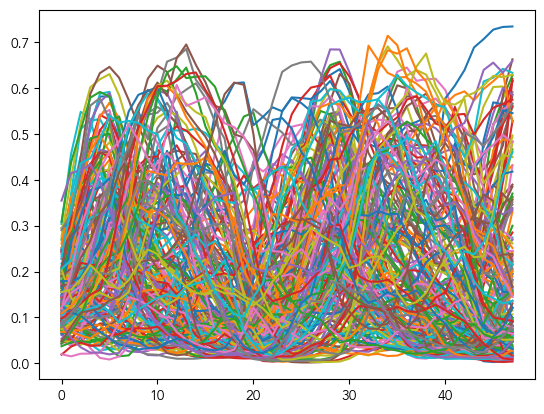

In [5]:
day = 216
interval = 18

dx_ = np.array([
    (
        t_ts + timedelta(minutes=0)
    ).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
    for t_ts in t_ts_[day, interval]
])

_fdu = functional_dynamic_update(
    _distances = {'temporal': 'seasonal_equinox', 'spatial': 'graph', 'fusion': 'None'},
    name = region,
    date = dx_[24],
)
print(_fdu.name, _fdu.date)

F_tr_p_ = F_tr_[:, interval, :]
E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
print(F_tr_p_.shape, E_tr_p_.shape)

_fdu.fit(
    F_tr_p_, E_tr_p_, dt_, 
    X_ = X_tr_, 
    t_ = d_tr_, 
    n_samples_per_hour=1,
)

f_ = F_ts_[day, interval, :24]
f_hat_ = F_ts_[day, interval, 24:]
e_ = E_ts_[day, interval, ...]
e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)

M_ = _fdu.predict(
    f_, e_p_, X_ts_[day], d_ts_[day],
    clique_order = get_hyper(hyper_, "clique_order", interval),
    forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
    forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
    lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
    length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
    length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
    length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
    sigma = get_hyper(hyper_, "sigma", interval),
    nu = get_hyper(hyper_, "nu", interval),
    kappa_0 = get_hyper(hyper_, "kappa", interval),
    kappa = get_hyper(hyper_, "kappa", interval),
    p_fusion = get_hyper(hyper_, "p_fusion", interval),
)
print(np.exp(_fdu.xi), _fdu.r)
x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
print(_fdu.name, _fdu.date)
print(x_, y_)
print(np.unique(X_tr_[_fdu.idx_fed_, 1]))

file_name = f"{resource}-{region}-{day}-{interval}-zone"
print(file_name)

e_p_[:24] = np.nan
E_tr_p_[:, :24] = np.nan
print(e_p_.shape, E_tr_p_.shape)
    
plt.figure()
plt.plot(M_.T)
plt.show()

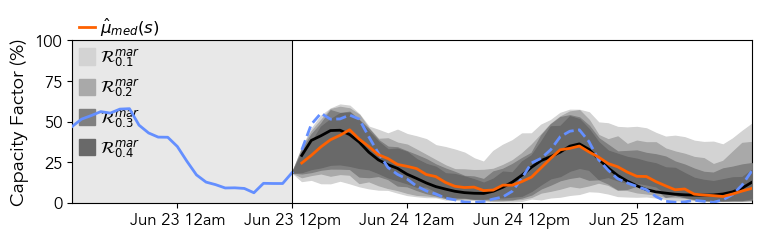

In [127]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(
    _fdu.M_ext_, 
    alpha_,
)

f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_region(
    _fdu.M_ext_, 
    _fdu.w_prime_,
    alpha_,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _wupper, _wlower, f_wmedian_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    color_med=palette_.loc[3, "ibm"],
    CR=r"$\mathcal{{R}}^{{mar}}_{{{}}}$",
    label = r"$\hat{\mu}_{med} (s)$",
    range_=[0, 71],
    legend_1=False,
    legend_2=True,
)

_ax.legend(
    frameon=False,
    #loc = 'upper center',
    loc=(0., 0.225),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=1,
)

plt.savefig(IMAGES / f"EDF-{file_name}.pdf")

plt.show()

(900, 48)
0 24
-0.09999999999999987 0.15787037037037033
[ 0.15787037 -0.06666667 -0.02268519 -0.1         0.00416667  0.09583333
  0.01759259  0.04953704 -0.07407407 -0.06157407]


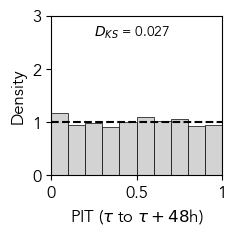

In [128]:
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description,
    VALIDATION,
)

print(pit_.shape)

_fig, _ax = plt.subplots(
    figsize = (2.25, 2.25), 
    constrained_layout = True
)

INTERVALS = [0, 6, 12, 18, 24, 30]

INTERVAL = INTERVALS[0]
LEAD = 24
bins = 10
print((INTERVAL), (INTERVAL + LEAD))
plotter.plot_pit(
    _fig, _ax, pit_[:, INTERVAL:(INTERVAL + LEAD)].flatten(), 
    v = 0.4,
    bins = bins,
    xlabel = r'PIT ($\tau$ to $\tau + 48$h)'
)

plt.savefig(
    IMAGES / f"PIT-{resource}-{INTERVAL}-{LEAD}-{interval}.pdf"
)

plt.show()

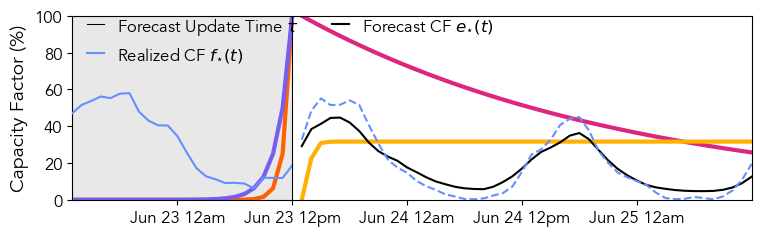

In [129]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_forecast_parameters(
    _fig, _ax, palette_,
    _fdu.phi_, _fdu.psi_, _fdu.eta_,
    f_, f_hat_, e_p_, dx_, dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    labels_1=True,
    labels_2=False,
)

_ax.legend(frameon=False,
           ncol=2,
           loc=(0.0125,0.7),
           #loc=(0.362,0.625),
           fontsize=12)

plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

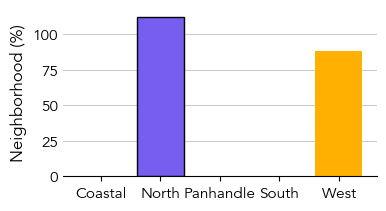

In [130]:
# Plot
_fig, _ax = plt.subplots(
    figsize=(3.75, 2), 
    constrained_layout=True
)

plotter.plot_zone_neighborhood(
    _fig, 
    _ax, 
    palette_,
    X_tr_, 
    regions_, 
    _fdu.idx_x_, 
    region,
)

plt.savefig(IMAGES / f"spatial_neibors-{file_name}.pdf")

plt.show()

2025-06-23 01:00:00-05:00


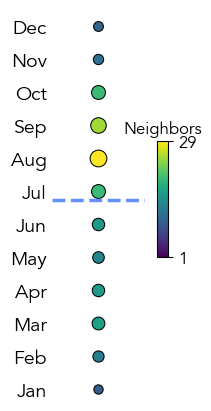

In [131]:
_fig, _ax = plt.subplots(
    figsize=(2, 4), 
    constrained_layout=True
)

print(t_ts_[day, interval, 12])
# plotter.scenarios_frequency_dates(
#     _fig, _ax, palette_,
#     _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
#     t_tr_[:, interval, 12],
#     t_ts_[day, interval, 12], 
#     scale=1,
#     colorbar=True,
# )
plotter.scenarios_frequency_dates(
    _fig, 
    _ax, 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_,
    t_tr_[:, interval, 12], 
    t_ts_[day, interval, 12],
    scale = 5,
    colorbar = True,
)

plt.savefig(IMAGES / f"temporal_neibors-{file_name}.pdf")

plt.show()

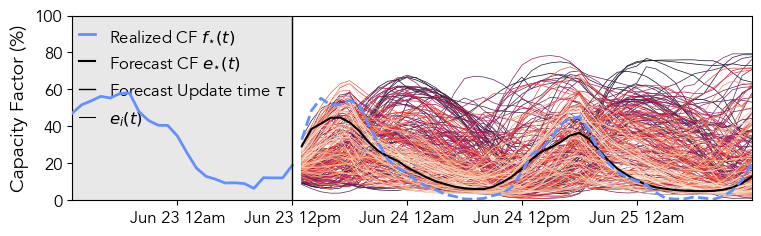

In [132]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_forecasts(
    _fig, _ax, palette_, 
    E_tr_p_, _fdu.w_fed_, _fdu.idx_x_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=True,
    legend_2=True,
)

_ax.legend(
    loc=(0., 0.35),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


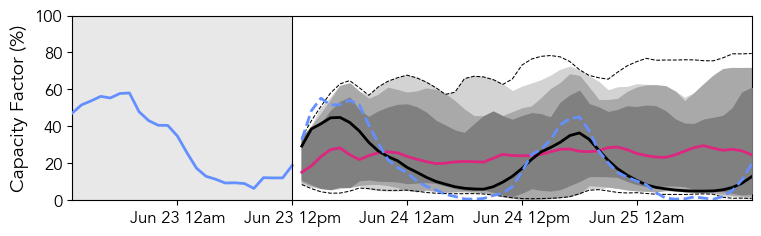

In [133]:
depth_score_, depth_rank_ = _fdu.get_depth(_depth, E_tr_p_[_fdu.idx_x_, :])


# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    E_tr_p_[_fdu.idx_x_, :], 
    depth_score_,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.3675, .55),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_box_forecast-{file_name}.pdf")

plt.show()

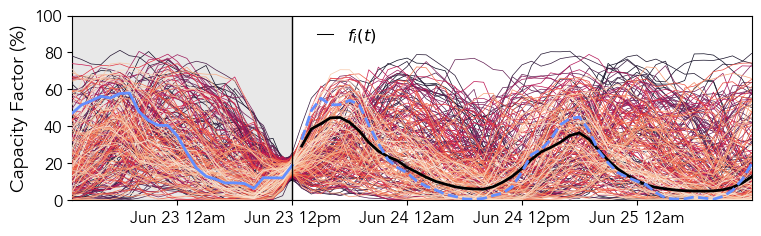

In [134]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_neighbors(
    _fig, _ax, palette_, 
    F_tr_p_, _fdu.w_fed_, _fdu.idx_x_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=True,
    legend_2=False,
)

_ax.legend(
    loc=(0.35, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(200, 72)
(200,)


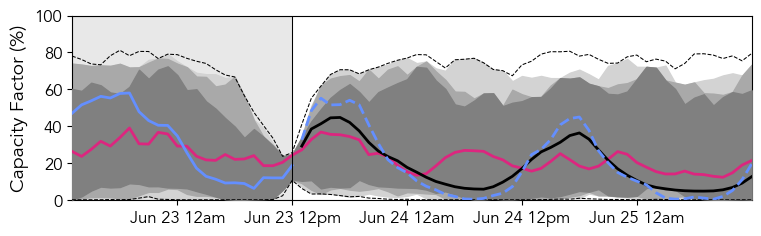

In [162]:
print(F_tr_p_[_fdu.idx_x_, :].shape)

depth_score_, depth_rank_ = _fdu.get_depth(_depth, F_tr_p_[_fdu.idx_x_, :])
print(depth_score_.shape)
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    F_tr_p_[_fdu.idx_x_, :], 
    depth_score_,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    CR=r"$\mathcal{{R}}^{{bxp}}_{{{}}}$",
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .625),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3,
)

plt.savefig(IMAGES / f"{distance}_box_realized-{file_name}.pdf")

plt.show()

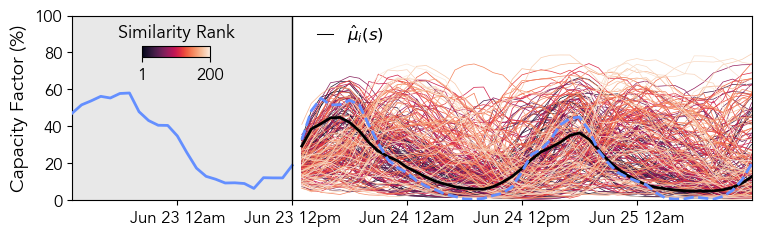

In [163]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_updates(
    _fig, _ax, palette_, M_, f_, f_hat_, e_p_, _fdu.w_fed_, _fdu.idx_x_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=True,
    legend_2=False,
    colorbar_pos = [500, 77.5, 425, 6],
)

_ax.legend(
    loc=(0.35, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

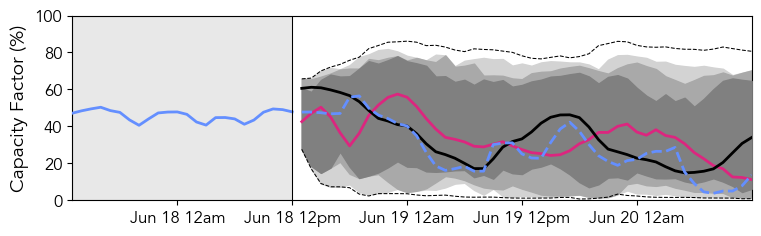

In [115]:
depth_score_, depth_rank_ = _fdu.get_depth(_depth, _fdu.M_)

# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    M_, 
    depth_score_,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    legend_1=False,
    legend_2=False,
)

plt.savefig(IMAGES / f"{distance}_box_fused-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


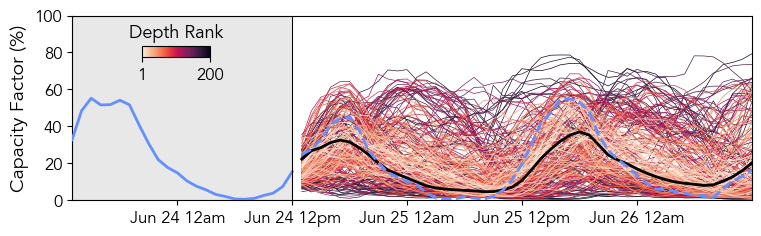

In [52]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

depth = "MBD"
depth_rank_ = _fDepth(_fdu.M_, depth, DEPTH).to_numpy()[:, 0]

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_p_, depth_rank_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    colorbar=True,
    colorbar_pos = [500, 77.5, 425, 6],
)

_ax.legend(
    frameon=False,
    loc=(0.3125, 0.8),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.2,
    ncol=5
)

plt.savefig(IMAGES / f"ranking-{depth}_{file_name}.pdf")

plt.show()

(192, 48)


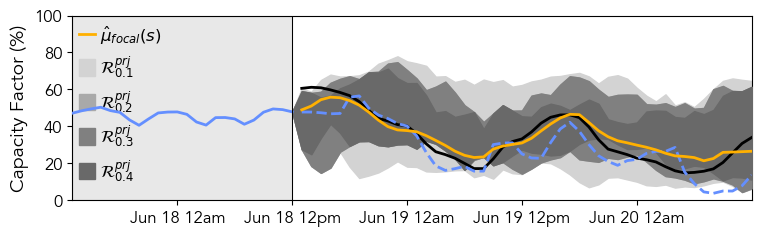

In [99]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

J_ = _fdu.focal_curve_envelope(
    _depth, 
    _fdu.M_ext_, 
    distance,
)
print(J_.shape)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score,
)

f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_region(
    alpha_, 
    k_*2,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    color_med=palette_.loc[4, "ibm"],
    label=r"$\hat{\mu}_{focal} (s)$",
    CR=r"$\mathcal{{R}}^{{prj}}_{{{}}}$",
    range_=[0, 71],
    legend_1=False,
    legend_2=True,
)

_ax.legend(
    frameon=False,
    loc=(0., 0.05),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=1,
)

plt.savefig(IMAGES / f"focal_curve_envelop-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


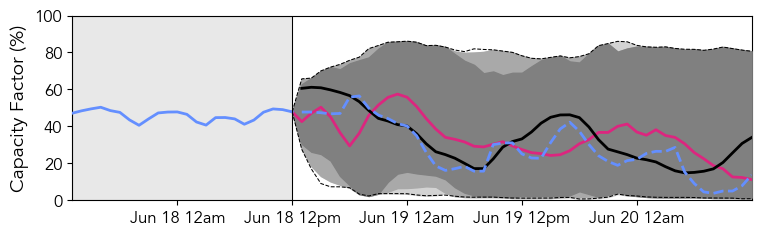

In [109]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    _fdu.M_ext_, 
    depth_rank_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.2,
    ncol = 6
)

plt.savefig(IMAGES / f"fboxplot-{depth}_{file_name}.pdf")

plt.show()

 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_71716/601652512.py:44: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_71716/601652512.py:44: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.


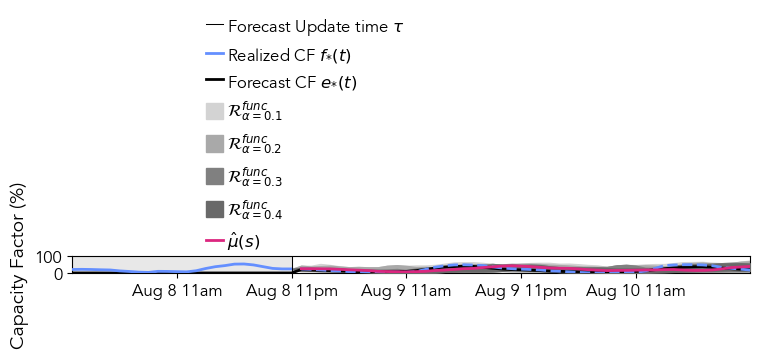

In [171]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

k_ = get_band_fraction(envelope_, alpha_, interval, distance, score)

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(
    _depth, 
    _fdu.M_ext_, 
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(
    figsize = (7.5, 2.5), 
    constrained_layout = True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval=24,
    n=720,
    color_med=palette_.loc[2, "ibm"],
    label=r"$\hat{\mu} (s)$",
    CR=r"$\mathcal{{R}}^{{func}}_{{\alpha={}}}$",
    range_=[0, 71],
    legend_1=True,
    legend_2=True,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=1,
)

plt.savefig(IMAGES / f"{distance}_bands-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(48,)


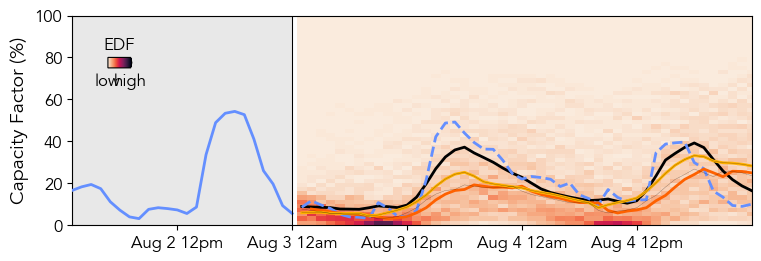

In [760]:
_fig, _ax = plt.subplots(
    figsize = (7.5, 2.5), 
    constrained_layout = True
)

plotter.plot_density_heatmap(
    _fig, _ax, palette_,
    M_, f_median_ext_, f_deepest_ext_, f_focal_ext_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n=720,
    range_=[0, 71],
    colorbar=True,
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .8),
    fontsize = 12,
    ncol = 3
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

In [21]:
print(F_ts_.shape)

(360, 24, 72)


In [148]:
day = 215
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

F_curves_ = []
E_curves_ = []
M_curves_ = []
D_curves_ = []
G_curves_ = []
dxs_ = []
dts_ = []

for i, day in enumerate([213, 214, 215, 216, 217, 218, 219, 220, 221]):
    for interval in range(0, 6, 1):
    
        dx_ = np.array([
            (
                t_ts + timedelta(minutes=0)
            ).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
            for t_ts in t_ts_[day, interval]
        ])

        F_tr_p_ = F_tr_[:, interval, :]
        E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
        #print(F_tr_p_.shape, E_tr_p_.shape)
        
        _fdu.fit(
            F_tr_p_, E_tr_p_, dt_, 
            X_ = X_tr_, 
            t_ = d_tr_, 
            n_samples_per_hour=1,
        )
    
        f_ = F_ts_[day, interval, :24]
        f_hat_ = F_ts_[day, interval, 24:]
        e_ = E_ts_[day, interval, ...]
        e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
        #print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)
        
        M_ = _fdu.predict(
            f_, e_p_, X_ts_[day], d_ts_[day],
            clique_order = get_hyper(hyper_, "clique_order", interval),
            forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
            forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
            lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
            length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
            length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
            length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
            sigma = get_hyper(hyper_, "sigma", interval),
            nu = get_hyper(hyper_, "nu", interval),
            kappa_0 = get_hyper(hyper_, "kappa", interval),
            kappa = get_hyper(hyper_, "kappa", interval),
            p_fusion = get_hyper(hyper_, "p_fusion", interval),
        )
    
        f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(_fdu.M_ext_, alpha_)
    
        k_ = get_band_fraction(
            envelope_, 
            alpha_, 
            interval, 
            "MBD", 
            "FCS",
        )
        
        f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(
            _depth, 
            _fdu.M_ext_, 
            alpha_, 
            k_
        )
        
        k_ = get_band_fraction(
            envelope_, 
            alpha_, 
            interval, 
            "fknn", 
            "FCS",
        )
        
        J_ = _fdu.focal_curve_envelope(
            _depth, 
            _fdu.M_ext_, 
            "fknn"
        )
        
        f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_bands(
            alpha_, 
            k_,
        )
        e_ext_ = np.concatenate([f_median_ext_[0][np.newaxis], e_], axis = 0)
        M_curves_.append(f_median_ext_)
        E_curves_.append(e_ext_)
        D_curves_.append(f_deepest_ext_)
        F_curves_.append(f_hat_)
        G_curves_.append(f_focal_ext_)

        dts_.append(dt_ + interval*60 + i*24*60)
        dxs_.append(dx_)
        
print(len(F_curves_), len(M_curves_), len(D_curves_))

54 54 54


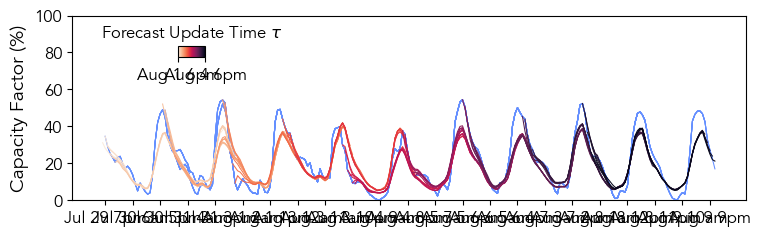

In [149]:
def plot_zonal_dynamic_update(
    _fig,
    _ax,
    palette_,
    F_curves_,
    M_curves_,
    dxs_,
    dts_,
    legend=False,
    colorbar=True,
    label=r"$\bar{f} (s)$",
    n = 120,
    range_=[],
):
    #print(np.unique(np.array(dxs_).flatten()))
    dx = np.array(dxs_).flatten()
    dt, idx_ = np.unique(np.array(dts_).flatten(), return_index=True)
    dt = dt[:-23]
    idx_ = idx_[:-23]

    dx = dx[idx_]
    
    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(0.0, len(F_curves_))

    _ax.plot(
        [], [], 
        lw=0.75, 
        label=label if legend else None, 
        c="k"
    )

    for i in range(len(F_curves_)):
        _ax.plot(
            dts_[i][:-24],
            100*F_curves_[i],
            c=palette_.loc[0, "ibm"],
            lw=0.75,
            zorder=8,
        )
        
    for i in range(len(M_curves_)):
        _ax.plot(
            dts_[i][:-23] - 60,
            100*M_curves_[i],
            c=_cmap(_norm(i)),
            lw=0.75,
            zorder=8,
        )

    idx_ = (dt % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt[idx_], dx[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    #_ax.set_xlim(dt_[range_[0]], dt_[range_[1]])

    _ax.tick_params(axis="both", labelsize=12)

    if colorbar:
        cbar = _fig.colorbar(
            cm.ScalarMappable(_norm, _cmap),
            cax=_ax.inset_axes([1750, 77.5, 650, 6], transform=_ax.transData),
            orientation="horizontal",
        )

        cbar.set_ticks([0, len(F_curves_)], labels=["Aug 1 6pm", "Aug 4 6pm"], size=12)

        # cbar.ax.tick_params(length=0)

        cbar.ax.set_title(r"Forecast Update Time $\tau$", rotation=0, size=12)


_fig, _ax = plt.subplots(
    figsize = (7.5, 2.25), 
    constrained_layout = True
)

plot_zonal_dynamic_update(
    _fig, _ax, palette_, F_curves_, E_curves_, dxs_, dts_, 
    range_=[0, 95],
    n = 220)

#plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

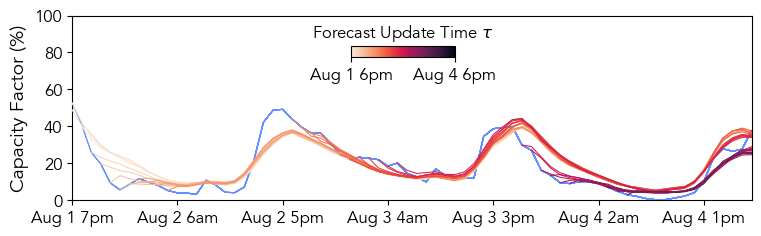

In [139]:
_fig, _ax = plt.subplots(
    figsize = (7.5, 2.25), 
    constrained_layout = True
)

plot_zonal_dynamic_update(
    _fig, _ax, palette_, F_curves_, E_curves_, dxs_, dts_, 
    range_=[0, 71],
    n = 220)

#plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()